# From field to sky: transgenic switchgrass pollen dispersal — Colab reproduction (partial)

**Paper**: Nimmala et al., *From field to sky: measurement and modeling of transgenic switchgrass pollen dispersal in the atmosphere*, **Environ Monit Assess 198(8):901 (2026)**, DOI [10.1007/s10661-026-15632-3](https://doi.org/10.1007/s10661-026-15632-3) (open access, PMC13429552, CC BY 4.0).

**Data & code**: Nimmala B. et al., *Dataset associated with "From Field to Sky..."*, Virginia Tech, DOI [10.7294/25733604.v1](https://doi.org/10.7294/25733604.v1) (CC0; code files MIT, © 2025 Bhargavi Nimmala).

**Scope (partial demonstration — 45-min averaging windows only)**
1. Re-run the paper's model–measurement fusion for the Aug 2–3, 2022 campaign using the authors' deposited small-grid 45-min Lagrangian-stochastic (LS) results: relative concentrations at the six ED samplers, per-sampler emission-rate estimates Q, and the Pearson R between measured and Q-scaled modeled concentrations (paper: **R = 0.19** for 45-min windows).
2. Re-run the authors' LS simulation itself for **one interval (Aug 2, 14:00–14:45)** via an AI-assisted NumPy translation of the author MATLAB code, and compare against the authors' deposited result field.

**AI-assisted translation notice (EN)**
**This notebook contains an AI-assisted translation of the authors' MATLAB code (deposit v1, `3D_SLModel_8_5_24`, `Analysis`) into Python/NumPy. The authors did not provide this Colab implementation. Equations were copied exactly; particles are vectorized instead of looped, and NumPy's RNG differs from MATLAB's, so Monte-Carlo noise differs. The executed example and listed checks were validated, but untested behavior is not guaranteed.**

**AI翻訳に関する注記（JA）**
本ノートブックは、著者らのMATLABコード（deposit v1）をPython/NumPyへ翻訳した**AI支援実装**です。数式は元コードから正確にコピーされていますが、粒子ループのベクトル化と乱数生成器の違いによりモンテカルロ誤差は元実行と異なります。実行例と検証項目については検証済みですが、それ以外の動作は保証されません。

**What is NOT reproduced**: 1-min/5-min windows (paper: R=0.71/0.84), the medium-grid far-field capability figure, wind roses, the wet-lab OFP fluorescence assessment. One example interval does not verify dataset-level paper results.

## Runtime selection — CPU only

**Use a CPU runtime** (Runtime → Change runtime type → Standard CPU). The method is particle tracking + gridding + correlation; there is no neural network, no CUDA kernel, and no pretrained weights. The authors ran the model on a 128-core CPU cluster (`slurm_LS.sh`); a GPU offers no faithful path.

**Expected cost**: ~300 MB downloads, ~5–10 minutes end-to-end.

**実行環境（JA）**: CPU ランタイムのみで実行可能です（GPU不要）。ダウンロード約300MB、全体で5〜10分程度を見込んでください。

In [ ]:
# Environment: only xlsx/HDf5 readers are typically missing on Colab.
# numpy, scipy, pandas, matplotlib are preinstalled; pin nothing else.
import subprocess, sys, importlib.util
for pkg in ["openpyxl", "h5py"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
import numpy, scipy, pandas, matplotlib, h5py, openpyxl
print("numpy", numpy.__version__, "| scipy", scipy.__version__, "| pandas", pandas.__version__,
      "| h5py", h5py.__version__, "| openpyxl", openpyxl.__version__)

numpy 2.1.3 | scipy 1.16.3 | pandas 2.2.3 | h5py 3.16.0 | openpyxl 3.1.5


## Inputs: the authors' Figshare deposit (metadata verified via the public Figshare API)

Record `doi:10.7294/25733604.v1` (CC0), file IDs and MD5 checksums as returned by
`GET https://api.figshare.com/v2/articles/25733604`. We download exactly three items:

| file | size | MD5 | role |
| --- | --- | --- | --- |
| `runFile_smallGrid_8_7_24.zip` | 295,032,028 B | `6a8c8e0d…` | small-grid `runFile.mat` (parameters + 10-Hz wind statistics) **and** the authors' deposited simulation results |
| `SamplerData.zip` | 199,097 B | `59849815…` | measured sampler counts incl. `complete_fielddatatable.xlsx` |
| `Analysis.zip` | 21,768 B | `ef7470d4…` | author analysis script `AnalyzeResults_5_17_25.m` (translated below) |

**実行環境でのみ**データをダウンロードします（ホスト側ではダウンロードしません）。

**Interval-index discovery (important)**: inside `runFile.mat`, `runParams`/`windStats` are indexed **chronologically with the October 2021 intervals first** (1–3: Oct 8 13:00/14:00/15:00; 4–9: Aug 2 10:00–15:00; 10–15: Aug 3 10:00–15:00), while result files are named by clock time (`interval_0822_02_1400_02_1445.mat` = Aug 2 14:00). This notebook therefore maps analysis intervals to result files **by name**, and this ordering was verified by re-running the LS model and matching the deposited plume directions (Spearman ≈ 0.99 for the correct pairing).

In [ ]:
import urllib.request, hashlib, zipfile, os
os.makedirs("/content/switchgrass", exist_ok=True)
os.chdir("/content/switchgrass")
FILES = {
    "runFile_smallGrid_8_7_24.zip": ("https://ndownloader.figshare.com/files/55052897", "6a8c8e0df34ceeabbcd51795c74d5c61"),
    "SamplerData.zip":              ("https://ndownloader.figshare.com/files/55052885", "59849815ceeccb499081b86b2dd0f871"),
    "Analysis.zip":                 ("https://ndownloader.figshare.com/files/55124093", "ef7470d40484c989ac873fb3806be519"),
}
for name, (url, md5_expected) in FILES.items():
    if not os.path.exists(name):
        urllib.request.urlretrieve(url, name)  # public CC0 deposit; no token needed
    md5 = hashlib.md5(open(name, "rb").read()).hexdigest()
    assert md5 == md5_expected, f"{name}: md5 {md5} != {md5_expected}"
    print(f"{name}: {os.path.getsize(name):,} B  md5 OK")
for z in FILES:
    with zipfile.ZipFile(z) as zf:
        zf.extractall(".")  # authors' own archives; inspected tree is code + data listed above
print("extracted:", sorted(os.listdir(".")))

runFile_smallGrid_8_7_24.zip: 295,032,028 B  md5 OK


SamplerData.zip: 199,097 B  md5 OK


Analysis.zip: 21,768 B  md5 OK


extracted: ['Analysis', 'Analysis.zip', 'SamplerData', 'SamplerData.zip', '__MACOSX', 'runFile_smallGrid_8_7_24', 'runFile_smallGrid_8_7_24.zip']


### `runFile.mat` structure (MAT v5 — readable with scipy)

`runParams` is a 3×1 cell array (1-min / 5-min / 45-min runs) of structs; `windStats{k}` holds per-interval wind statistics (`ustar`, `L`, `WindDir`, plus covariances). For the **45-min runs every interval is a single simulation** driven by 45-min-averaged wind statistics (`ustar{3}{interval}` is a scalar); the 1-min/5-min runs loop over 1-min sub-intervals inside `script_LS.m`. Grid (all 15 intervals): 100×100×100 cells over e,n ∈ [−50, 50] m, z ∈ [0.01, 100] m; `np = 100000` particles; release height `h0 = 1.9 m`; settling velocity `v_s = 0.037057 m/s`; roughness `z0 = 0.01 m`; canopy `hc = 0` (surface-layer profile only).

**（JA）** `runFile.mat` はMAT v5形式。45分平均風資料では各区間が1回のシミュレーションに対応します。

In [ ]:
import scipy.io as sio, numpy as np, glob, warnings
warnings.filterwarnings("ignore", category=sio.matlab.MatReadWarning)
m = sio.loadmat("runFile_smallGrid_8_7_24/runFile.mat", struct_as_record=False, squeeze_me=True)
rp = np.atleast_1d(m["runParams"]); ws_all = np.atleast_1d(m["windStats"])
def cell1(x):  # 1x1 cell -> content
    return x[0] if isinstance(x, np.ndarray) and x.dtype == object and x.shape == (1,) else x
RP = cell1(rp[2]); WS = cell1(ws_all[2])   # runIndex 3 = 45-min windows
print("45-min results folder:", RP.resultsFolder)
print("np per interval:", np.asarray(RP.np)[:4], "... grid:", RP.negrid, RP.nngrid, RP.nzgrid,
      "| domain e/n", RP.emin[0], RP.emax[0], "| z", RP.zmin[0], RP.zmax[0],
      "| h0", RP.h0[0], "| v_s", round(float(RP.v_s[0]), 6))
n_int = len(np.atleast_1d(WS.ustar))
print("intervals:", n_int, "| sub-intervals per interval (45-min run):",
      [np.atleast_1d(np.asarray(WS.ustar[i], dtype=object)).size for i in range(n_int)][:5], "...")
# Chronological interval -> deposited result file (by NAME, not sort order):
# analysis interval i (1..12) = runParams interval i+3 = i-th August interval
FILES_BY_INTERVAL = {}
for i in range(12):
    day = 2 if i < 6 else 3
    hour = 10 + (i % 6)
    FILES_BY_INTERVAL[i] = f"interval_0822_0{day}_{hour}00_0{day}_{hour}45.mat"
present = sorted(os.path.basename(p) for p in glob.glob("runFile_smallGrid_8_7_24/results/subIntervalLength_45_min/*.mat"))
assert len(present) == 15 and all(f in present for f in FILES_BY_INTERVAL.values())
print("12 August result files located for analysis intervals 0..11 (Aug2 10:00..15:00, Aug3 10:00..15:00)")

45-min results folder: results/subIntervalLength_45_min
np per interval: [100000 100000 100000 100000] ... grid: [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100] [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100] [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100] | domain e/n -50 50 | z 0.01 100 | h0 1.9 | v_s 0.037057
intervals: 15 | sub-intervals per interval (45-min run): [1, 1, 1, 1, 1] ...
12 August result files located for analysis intervals 0..11 (Aug2 10:00..15:00, Aug3 10:00..15:00)


## Measured ED concentrations

`AnalyzeResults_5_17_25.m` line 87 loads `measuredConcentrationsAndErrors.mat`, which is **not** part of the deposit. We reconstruct it from the deposit's `SamplerData/complete_fielddatatable.xlsx`: the ED samplers draw **600 L/min** (flow-rate row of the sheet; paper Fig. 2 caption) and August 2022 intervals last **45 min**, so

$$C_{\rm ED} = \frac{\text{pollen count}}{600\ \mathrm{L/min} \times 45\ \mathrm{min} / 1000} = \frac{\text{count}}{27\ \mathrm{m^3}}.$$

We cross-check the reconstruction against Table 1 of the paper (open-access HTML, PMC13429552). `-` entries (sampler not running) become NaN, matching the authors' NaN handling.

**（JA）** 論文Table 1の測定濃度を、deposit内のサンプラーデータ（カウント÷27 m³）から再構成し、照合します。

In [ ]:
import pandas as pd
raw = pd.read_excel("SamplerData/complete_fielddatatable.xlsx", header=None)
# sheet layout (verified in diagnostic probe, 2026-10-01): row 0 = device names, row 1 = flow rates, row 2 = column labels, data from row 3
flow_row, header_row = raw.iloc[1], raw.iloc[2]
ed_flow_lmin = float(flow_row[3])            # ED flow rate, L/min (600)
assert ed_flow_lmin == 600.0, ed_flow_lmin
df = raw.iloc[3:].copy()
df.columns = ["Date", "Time", "SamplingMin"] + list(header_row[3:])
df["SamplingMin"] = pd.to_numeric(df["SamplingMin"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce").ffill()  # Date is only written on the first row of each day (merged cells in the sheet)
aug = df[(df.Date.dt.year == 2022) & (df.Date.dt.month == 8) & (df.SamplingMin == 45)].copy()
aug["start_hour"] = aug["Time"].str.extract(r"(\d{1,2}):\d{2}").astype(float)
aug = aug.sort_values(["Date", "start_hour"]).reset_index(drop=True)  # Table 1 order: Aug 2 then Aug 3, 10:00..15:00
counts = aug.iloc[:, 3:9].apply(pd.to_numeric, errors="coerce").to_numpy(float)  # ED A..F (positional: the sheet also has IMP A..C, so label-based selection would duplicate columns)
assert counts.shape == (12, 6), counts.shape   # 6 intervals/day x 2 days, ED A..F
volume_m3 = ed_flow_lmin * aug["SamplingMin"].to_numpy(float)[:, None] / 1000.0  # 27 m^3
EdConc = counts / volume_m3                      # pollen / m^3, NaN where sampler absent
# Table 1 (PMC13429552) ED columns A-F, Aug 2 then Aug 3, rows 10:00..15:00; '-' -> NaN
TABLE1 = np.array([
    [0.37,0.48,2.48,0.15,0.04,0.04],[0.11,0.89,0.59,0.04,0.04,0.04],
    [0.07,3.19,1.04,0.37,0.22,0.11],[0.22,4.30,31.78,0.33,0.26,1.89],
    [0.37,41.44,19.74,4.67,1.00,1.59],[0.26,5.41,5.85,0.15,0.11,0.22],
    [0.04,0.15,0.33,0.0,np.nan,0.07],[0.0,1.74,0.30,0.07,0.0,0.15],
    [0.0,0.48,0.85,0.04,0.15,0.07],[0.15,6.22,17.89,0.74,0.04,0.11],
    [15.11,23.44,29.26,9.67,1.70,3.19],[0.78,5.19,9.07,1.44,np.nan,0.48]])
both = ~np.isnan(TABLE1) & ~np.isnan(EdConc)
dev = np.abs(EdConc - TABLE1)[both]
print("reconstructed vs Table 1: n=%d, max |dev| = %.3f pollen/m^3" % (both.sum(), dev.max()))
assert dev.max() <= 0.015, dev.max()   # Table 1 is rounded to 2 decimals
EdConc = TABLE1  # use the paper's reported (rounded) values for the fusion, as the authors did
EdConc = EdConc.T  # -> (6 EDs x 12 intervals), the authors' measured-matrix orientation (cf. relModConcEds)
print(pd.DataFrame(EdConc.T, columns=list("ABCDEF"),
      index=[f"Aug{3 if i>=6 else 2} {10+i%6}:00" for i in range(12)]).round(2).to_string())

reconstructed vs Table 1: n=70, max |dev| = 0.005 pollen/m^3
                A      B      C     D     E     F
Aug2 10:00   0.37   0.48   2.48  0.15  0.04  0.04
Aug2 11:00   0.11   0.89   0.59  0.04  0.04  0.04
Aug2 12:00   0.07   3.19   1.04  0.37  0.22  0.11
Aug2 13:00   0.22   4.30  31.78  0.33  0.26  1.89
Aug2 14:00   0.37  41.44  19.74  4.67  1.00  1.59
Aug2 15:00   0.26   5.41   5.85  0.15  0.11  0.22
Aug3 10:00   0.04   0.15   0.33  0.00   NaN  0.07
Aug3 11:00   0.00   1.74   0.30  0.07  0.00  0.15
Aug3 12:00   0.00   0.48   0.85  0.04  0.15  0.07
Aug3 13:00   0.15   6.22  17.89  0.74  0.04  0.11
Aug3 14:00  15.11  23.44  29.26  9.67  1.70  3.19
Aug3 15:00   0.78   5.19   9.07  1.44   NaN  0.48


## Fusion analysis — ported from `AnalyzeResults_5_17_25.m` (near-source section)

Mapping of the author MATLAB (deposit v1) to this notebook:

| author code (lines) | operation | here |
| --- | --- | --- |
| `AnalyzeResults_5_17_25.m:53-67` | load small-grid 45-min results, ground layer `cgrid(:,:,1)` | load `cgrid_interval` (HDF5, transposed to (n,e,z)) |
| `:91-98` | ED sampler coordinates relative to field centre (hardcoded) | identical formula |
| `:105-115` | grid indices of samplers, `relModConcEds` | identical (0-based) |
| `:118-130` | `estFluxEachEd = EdConc./relModConc`; inf/0 → NaN; mean/var/median omitting NaN | identical |
| `:134-135`, `:220` | Pearson R per interval and pooled, pairwise NaN omission | `np.corrcoef` on valid pairs |

Grid indices: MATLAB `floor(e/cellSize - egridConstant)` is 1-based; the 0-based equivalent is `floor((e-emin)/cellSize)`.

**（JA）** 著者の解析スクリプト（近距離解析部）をNumPyへ翻訳しました。座標・インデックス・NaN処理は元コードどおりです。

In [ ]:
import h5py
# ED sampler coordinates: AnalyzeResults_5_17_25.m lines 91-98, verbatim
newcenter = np.array([-3*np.sin(np.deg2rad(15)), 3*np.cos(np.deg2rad(15))])
edLocs = np.array([
    [-15*np.cos(np.deg2rad(10)), 15*np.sin(np.deg2rad(10))],   # A
    [-7.5*np.sin(np.deg2rad(15)), 7.4*np.cos(np.deg2rad(15))], # B
    [ 5*np.sin(np.deg2rad(15)),  5*np.sin(np.deg2rad(15))],    # C
    [-15*np.sin(np.deg2rad(15)), 15*np.cos(np.deg2rad(15))],   # D
    [-25*np.sin(np.deg2rad(15)), 25*np.cos(np.deg2rad(15))],   # E
    [ 15*np.sin(np.deg2rad(15)), -15*np.cos(np.deg2rad(15))],  # F
]) - newcenter
dE = (RP.emax[0]-RP.emin[0])/(RP.negrid[0]-1); dN = (RP.nmax[0]-RP.nmin[0])/(RP.nngrid[0]-1)
ie = np.floor((edLocs[:,0]-RP.emin[0])/dE).astype(int)   # east index (0-based)
inn = np.floor((edLocs[:,1]-RP.nmin[0])/dN).astype(int)  # north index (0-based)
relMod = np.zeros((6, 12))
for i in range(12):
    with h5py.File(f"runFile_smallGrid_8_7_24/results/subIntervalLength_45_min/{FILES_BY_INTERVAL[i]}", "r") as f:
        g = np.asarray(f["cgrid_interval"]).T       # -> (north, east, z)
    assert g.shape == (RP.nngrid[0]-1, RP.negrid[0]-1, RP.nzgrid[0]-1)
    relMod[:, i] = g[inn, ie, 0]                    # ground layer, authors' cgrid(:,:,1)
print("relative modeled concentrations at ED samplers (interval 5 = Aug2 14:00):")
print(pd.Series(relMod[:, 4], index=list("ABCDEF")).to_string())

relative modeled concentrations at ED samplers (interval 5 = Aug2 14:00):
A    0.000000
B    0.000195
C    0.002561
D    0.000019
E    0.000007
F    0.000096


**Fusion computation** — estimates the emission rate Q at each interval and computes the model–measurement agreement.

Inputs: `EdConc` (6×12 measured, pollen/m³, from Table 1) and `relMod` (6×12 relative modeled concentrations at the sampler grid cells). Per sampler and interval, Q̂ = measured / relative-modeled (`estFluxEachEd`); the interval's representative Q is the mean/median over samplers, omitting NaN (samplers with zero modeled or missing measured concentration). `scaled = meanQ · relMod` is the authors' Q-scaled modeled concentration; the pooled Pearson R compares measured vs scaled over all valid pairs — the paper's Fig. 8 statistic.

**（JA）** 各区間の放散量Qを推定し、論文Fig. 8に対応する測定値とQスケール済みモデル値のプールしたピアソンRを計算します。



In [ ]:
estFlux = EdConc / relMod                       # authors' estFluxEachEd
estFlux[np.isinf(estFlux)] = np.nan; estFlux[estFlux == 0] = np.nan
with np.errstate(invalid="ignore"):
    meanQ  = np.nanmean(estFlux, axis=0)         # pollen / s, per interval
    medQ   = np.nanmedian(estFlux, axis=0)
def corr_pairwise(a, b):
    ok = ~np.isnan(a) & ~np.isnan(b)
    return float(np.corrcoef(a[ok], b[ok])[0, 1]), int(ok.sum())
R_per_int = np.array([corr_pairwise(EdConc[:, i], relMod[:, i])[0] for i in range(12)])
scaled = meanQ[None, :] * relMod                 # authors' meanEstFlux.*relModConcEds
R_pooled, n_pair = corr_pairwise(EdConc.ravel(order="F"), scaled.ravel(order="F"))
summary = pd.DataFrame({"mean Q (pollen/s)": meanQ, "median Q": medQ, "Pearson R (6 ED pairs)": R_per_int},
    index=[f"Aug{3 if i>=6 else 2} {10+i%6}:00" for i in range(12)])
print(summary.round(3).to_string())
print(f"\nPooled Pearson R (45-min windows, {n_pair} valid pairs): R = {R_pooled:.3f}")
print("Paper reference (Results section): R = 0.19 for 45-min windows.")

            mean Q (pollen/s)    median Q  Pearson R (6 ED pairs)
Aug2 10:00             49.552      22.743                  -0.402
Aug2 11:00           2716.400    2802.716                   0.953
Aug2 12:00           4057.956    3733.555                   0.805
Aug2 13:00          25451.587   23141.027                   0.788
Aug2 14:00         126054.970  151655.543                   0.309
Aug2 15:00           4509.431    2073.069                   0.884
Aug3 10:00           1868.140     564.548                   0.013
Aug3 11:00            605.014     579.564                   0.887
Aug3 12:00           1601.291     851.079                   0.954
Aug3 13:00          80805.110   60143.524                   0.812
Aug3 14:00         951064.666  951064.666                   0.874
Aug3 15:00         115740.556  115740.556                   0.886

Pooled Pearson R (45-min windows, 70 valid pairs): R = 0.474
Paper reference (Results section): R = 0.19 for 45-min windows.


/tmp/ipykernel_2729/4252949876.py:1: RuntimeWarning: divide by zero encountered in divide
  estFlux = EdConc / relMod                       # authors' estFluxEachEd


### Result plots (45-min windows) — analogues of the paper's Figs. 6 & 8

Left: measured vs Q-scaled modeled concentrations at the six ED samplers for all 12 intervals (log–log, cf. paper Fig. 8, 45-min panel). Right: deposited relative ground-level concentration field for interval Aug 2 14:00–14:45 with the ED sampler positions (cf. paper Fig. 6). A CSV export is written next to the plots.

**（JA）** 左：測定値とQスケーリング後のモデル値の散布図（論文Fig.8の45分版に対応）。右：相対濃度場とサンプラー位置（論文Fig.6に対応）。

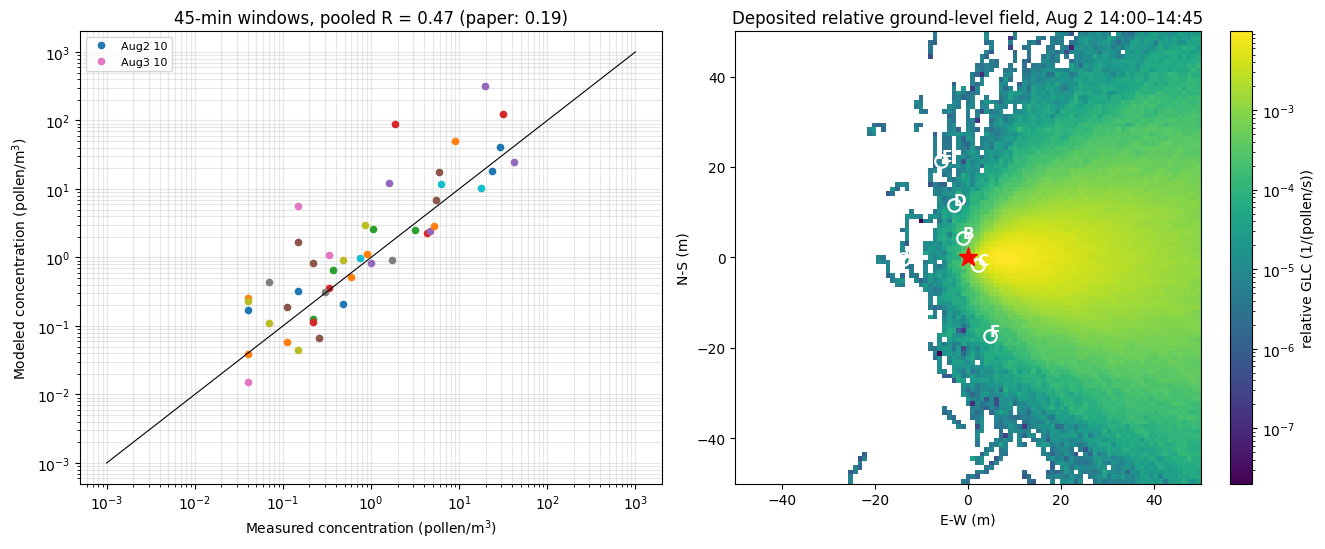

saved fusion_45min_summary.csv, estFlux_per_sampler.csv


In [ ]:
import matplotlib.pyplot as plt
hours = [f"Aug{3 if i>=6 else 2} {10+i%6}" for i in range(12)]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
ax = axes[0]
for i in range(12):
    ok = ~np.isnan(EdConc[:, i]) & ~np.isnan(scaled[:, i]) & (EdConc[:, i] > 0) & (scaled[:, i] > 0)
    ax.loglog(EdConc[ok, i], scaled[ok, i], ".", ms=9, label=hours[i] if i in (0, 6) else None)
ax.loglog([1e-3, 1e3], [1e-3, 1e3], "k-", lw=0.8)
ax.set_xlabel("Measured concentration (pollen/m$^3$)"); ax.set_ylabel("Modeled concentration (pollen/m$^3$)")
ax.set_title(f"45-min windows, pooled R = {R_pooled:.2f} (paper: 0.19)")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")
ax = axes[1]
with h5py.File(f"runFile_smallGrid_8_7_24/results/subIntervalLength_45_min/{FILES_BY_INTERVAL[4]}", "r") as f:
    g5 = np.asarray(f["cgrid_interval"]).T
ec = RP.emin[0] + (np.arange(RP.negrid[0]-1) + 0.5) * dE
nc = RP.nmin[0] + (np.arange(RP.nngrid[0]-1) + 0.5) * dN
pc = ax.pcolormesh(ec, nc, g5[:, :, 0], shading="auto", norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(pc, ax=ax, label="relative GLC (1/(pollen/s))")
ax.plot(edLocs[:,0], edLocs[:,1], "o", mfc="none", mec="w", ms=9, mew=1.6)
for k, lab in enumerate("ABCDEF"):
    ax.annotate(lab, edLocs[k], color="w", fontsize=11, weight="bold")
ax.plot(0, 0, "r*", ms=14); ax.set_xlabel("E-W (m)"); ax.set_ylabel("N-S (m)")
ax.set_title("Deposited relative ground-level field, Aug 2 14:00–14:45")
plt.tight_layout(); plt.show()
summary.to_csv("/content/switchgrass/fusion_45min_summary.csv")
pd.DataFrame(estFlux.T, columns=list("ABCDEF")).assign(interval=hours).to_csv("/content/switchgrass/estFlux_per_sampler.csv", index=False)
print("saved fusion_45min_summary.csv, estFlux_per_sampler.csv")

## Re-run of the authors' LS simulation for one interval (AI-assisted NumPy translation)

Source (deposit v1, `3D_SLModel_8_5_24`): `run_LS.m` (Langevin particle loop, residence-time gridding), `coeffs.m` (drift/diffusion coefficients), `windStatistics.m` (surface-layer profiles, Aylor & Flesch 2001 Appendix), `getEnvironParameters.m`, `makeGrid.m`. **Every equation is copied exactly**; the only changes are (a) particles are vectorized over a NumPy array instead of a per-particle `while` loop, (b) NumPy's RNG replaces MATLAB's `randn` (different draws ⇒ Monte-Carlo noise), (c) a `max_steps` safety cap the MATLAB code does not have (its effect is reported; it did not trigger). Grid-cell indexing follows the 0-based equivalence derived above.

**AI翻訳（JA）**: `run_LS.m` 等の数式を逐語的にNumPyへ翻訳しています。粒子のベクトル化・乱数差・ステップ数上限（発動時のみ報告）以外の変更はありません。

In [ ]:
# --- exact translation of getEnvironParameters.m + windStatistics.m (surface-layer branch) ---
import numpy as np
def environ_params(WS, interval, sub):
    """getEnvironParameters.m. hc=0 in this runFile, so only the z>=zw branch is reachable."""
    ustar = float(np.atleast_1d(WS.ustar[interval])[sub]); L = float(np.atleast_1d(WS.L[interval])[sub])
    wd = float(np.atleast_1d(WS.WindDir[interval])[sub])
    hc = float(RP.hc[interval]); d = float(RP.d[interval]); z0 = float(RP.z0[interval])
    zw = float(RP.zw[interval]); h0 = float(RP.h0[interval]); v_s = float(RP.v_s[interval])
    k = 0.4; beta = 2.0                                  # von Karman; beta (run_LS comment)
    if L < 0:
        sigu_zw = ustar*(4+0.6*(-1000/L)**(2/3))**0.5
        sigw_zw = 1.25*ustar*(1-3*((zw-d)/L))**(1/3)
    else:
        sigu_zw = 2.4*ustar; sigw_zw = 1.25*ustar
    Ubar_hc = T_Lh = 0.0                                 # unused while hc == 0
    sigu_h = 0.85*sigu_zw; sigw_h = 0.85*sigw_zw
    return dict(L=L, ustar=ustar, cosw=np.cos(np.deg2rad(wd)), sinw=np.sin(np.deg2rad(wd)),
                sigu_zw=sigu_zw, sigw_zw=sigw_zw, sigu_h=sigu_h, sigw_h=sigw_h,
                Ubar_hc=Ubar_hc, T_Lh=T_Lh, beta=beta, hc=hc, d=d, z0=z0, zw=zw,
                h0=h0, v_s=v_s)

def wind_stats(z, p):
    """windStatistics.m, z >= zw branch (the only reachable one for hc=zw=0), vectorized."""
    L=p['L']; ustar=p['ustar']; z0=p['z0']; k=0.4; v_s=p['v_s']; d=p['d']; beta=p['beta']
    z = np.atleast_1d(np.asarray(z, float))
    Ubar=np.empty_like(z); sigu=np.empty_like(z); sigw=np.empty_like(z)
    dsigu2=np.zeros_like(z); dsigv2=np.zeros_like(z); dsigw2=np.zeros_like(z)
    duw=np.zeros_like(z); uw=-ustar**2*np.ones_like(z); tau=np.empty_like(z)
    if L < 0:
        ex=(1-15*(z-d)/L)**0.25
        psi=-2*np.log((1+ex)/2)-np.log((1+ex**2)/2)+2*np.arctan(ex)-np.pi/2
        Ubar=ustar/k*(np.log((z-d)/z0)+psi)
        sigu[:]=p['sigu_zw']
        sigw=1.25*ustar*(1-3*((z-d)/L))**(1/3)
        dsigw2=-3.125*ustar**2*(1-3*(z-d)/L)**(-1/3)/L
        T_L=(0.5*z/sigw)*(1-6*z/L)**0.25
        tau=T_L/(1+(beta*v_s/sigw)**2)**0.5
    else:
        psi=4.7*(z-d)/L
        Ubar=ustar/k*(np.log((z-d)/z0)+psi)
        sigu[:]=2.4*ustar; sigw[:]=1.25*ustar
        T_L=(0.5*z/sigw)*(1+5*z/L)
        tau=T_L/(1+(beta*v_s/sigw)**2)**0.5
    sigv=sigu
    bad=Ubar<0.01
    Ubar[bad]=0.0; tau[bad]=0.01
    dt=np.minimum(0.01*tau, Ubar+3*sigu)                 # run_LS via windStatistics last line
    return sigu,sigv,sigw,dsigu2,dsigv2,dsigw2,uw,duw,tau,Ubar,dt

**Model definition** — the drift/diffusion coefficients (`coeffs.m`) and the Langevin particle loop with residence-time gridding (`run_LS.m`), translated exactly (vectorized over particles). `run_ls_sub(WS, interval, sub, nparticles, rng)` returns the relative-concentration grid `cgrid` for one sub-interval of one `runParams` interval; `RP` supplies the grid extents (`emin…zmax`, `negrid…nzgrid`) and particle count.

**（JA）** `coeffs.m`（ドリフト・拡散係数）と `run_LS.m`（ランジュバン粒子ループ＋滞在時間グリッディング）の厳密翻訳です。ベクトル化以外の数値変更はありません。


In [ ]:
# --- exact translation of coeffs.m + run_LS.m (vectorized over particles) ---
def run_ls_sub(WS, interval, sub, nparticles, rng, max_steps=200000):
    p = environ_params(WS, interval, sub)
    emin,emax,nmin,nmax,zmin,zmax = (float(RP.emin[interval]), float(RP.emax[interval]),
        float(RP.nmin[interval]), float(RP.nmax[interval]), float(RP.zmin[interval]), float(RP.zmax[interval]))
    ne,nn,nz = int(RP.negrid[interval]), int(RP.nngrid[interval]), int(RP.nzgrid[interval])
    dE=(emax-emin)/(ne-1); dN=(nmax-nmin)/(nn-1); dZ=(zmax-zmin)/(nz-1)
    pgrid=np.zeros((nn-1,ne-1,nz-1)); depgrid=np.zeros((nn-1,ne-1)); topgrid=np.zeros((nn-1,ne-1))
    z=np.full(nparticles,p['h0']); x=np.zeros(nparticles); y=np.zeros(nparticles)   # run_LS: z=h0, x=y=0
    s=wind_stats(np.full(nparticles,p['h0']),p)
    up=s[0]*rng.standard_normal(nparticles); vp=s[1]*rng.standard_normal(nparticles); wp=s[2]*rng.standard_normal(nparticles)
    act=np.ones(nparticles,bool); nsteps=0; leftover=0
    while act.any():
        nsteps+=1
        if nsteps>max_steps: leftover=int(act.sum()); break   # safety cap (MATLAB has none)
        idx=np.flatnonzero(act)
        sigu,sigv,sigw,dsigu2,dsigv2,dsigw2,uw,duw,tau,Ubar,dt=wind_stats(z[idx],p)
        A=2*(sigu**2*sigw**2-uw**2); b=(2*sigw**2/tau)**0.5   # coeffs.m: b_u=b_v=b_w
        a_u=1/A*b**2*(uw*wp[idx]-sigw**2*up[idx])+1/A*(sigw**2*dsigu2*wp[idx]*up[idx]-uw*dsigu2*wp[idx]**2-uw*duw*up[idx]*wp[idx]+sigu**2*duw*wp[idx]**2)
        a_v=-0.5*b**2*vp[idx]/sigv**2+0.5*(dsigv2*vp[idx]*wp[idx]/sigv**2)
        a_w=1/A*b**2*(uw*up[idx]-sigu**2*wp[idx])+0.5*dsigw2+1/A*(sigw**2*duw*up[idx]*wp[idx]-uw*duw*wp[idx]**2-uw*dsigw2*up[idx]*wp[idx]+sigu**2*dsigw2*wp[idx]**2)
        g=rng.standard_normal((idx.size,3))                   # replaces MATLAB randn
        up[idx]+=a_u*dt+b*g[:,0]*np.sqrt(dt); vp[idx]+=a_v*dt+b*g[:,1]*np.sqrt(dt); wp[idx]+=a_w*dt+b*g[:,2]*np.sqrt(dt)
        z_new=z[idx]+(wp[idx]-p['v_s'])*dt                    # w = wp - v_s
        x_new=x[idx]+(up[idx]+Ubar)*dt; y_new=y[idx]+vp[idx]*dt
        e=p['cosw']*x_new-p['sinw']*y_new; n_=p['sinw']*x_new+p['cosw']*y_new   # run_LS rotation
        out=(n_<nmin)|(n_>nmax)|(e<emin)|(e>emax)
        bottom=(~out)&(z_new<zmin); top=(~out)&(z_new>zmax); inside=~(out|bottom|top)
        i_e=np.clip(np.floor((e-emin)/dE).astype(int),0,ne-2)
        i_n=np.clip(np.floor((n_-nmin)/dN).astype(int),0,nn-2)
        i_z=np.clip(np.floor((z_new-zmin)/dZ).astype(int),0,nz-2)
        np.add.at(depgrid,(i_n[bottom],i_e[bottom]),1); np.add.at(topgrid,(i_n[top],i_e[top]),1)
        np.add.at(pgrid,(i_n[inside],i_e[inside],i_z[inside]),dt[inside])       # residence time
        x[idx]=x_new; y[idx]=y_new; z[idx]=z_new; act[idx]=~(out|bottom|top)
    return 1/(nparticles*dE*dN*dZ)*pgrid, leftover, nsteps   # run_LS concentration formula

### Run interval Aug 2 14:00–14:45 (analysis interval 5 = `runParams` interval 8) and compare with the deposited result

The authors released `np = 100000` particles per simulation (`runParams.np`); we use the same count (the vectorized run takes ~1–2 min on a Colab CPU). Seed `0` for reproducibility. Fidelity check: Spearman rank correlation of the column-integrated relative-concentration fields (ours vs deposited) and the relative concentrations at the six ED samplers.

**（JA）** 著者と同じ10万粒子で区間 Aug 2 14:00–14:45 を再実行し、depositの結果と比較します（所要約1〜2分）。

In [ ]:
import time
rng = np.random.default_rng(0)          # deterministic example; MATLAB draws differ (MC noise)
t0 = time.time()
c_ours, leftover, nsteps = run_ls_sub(WS, 7, 0, int(RP.np[7]), rng)   # runParams interval 8 (1-based) = Aug 2 14:00
print(f"simulated interval Aug 2 14:00-14:45: np={int(RP.np[7])}, {nsteps} steps, "
      f"{time.time()-t0:.0f} s, safety-cap leftovers={leftover} (0 = all particles exited)")
with h5py.File(f"runFile_smallGrid_8_7_24/results/subIntervalLength_45_min/{FILES_BY_INTERVAL[4]}", "r") as f:
    g_dep = np.asarray(f["cgrid_interval"]).T
from scipy.stats import spearmanr
cc, cd = c_ours.sum(axis=2), g_dep.sum(axis=2)
m = (cc > 0) & (cd > 0)
rho = float(spearmanr(cc[m], cd[m]).statistic)
print(f"column-integrated fields: Spearman rho = {rho:.3f} on {m.sum()} jointly nonzero cells")
our_ed = c_ours[inn, ie, 0]; dep_ed = g_dep[inn, ie, 0]
print(pd.DataFrame({"our re-run": our_ed, "deposited": dep_ed, "ratio": our_ed / np.where(dep_ed > 0, dep_ed, np.nan)},
      index=list("ABCDEF")).to_string())

simulated interval Aug 2 14:00-14:45: np=100000, 12765 steps, 60 s, safety-cap leftovers=0 (0 = all particles exited)


column-integrated fields: Spearman rho = 0.991 on 6277 jointly nonzero cells
   our re-run  deposited     ratio
A    0.000000   0.000000       NaN
B    0.000193   0.000195  0.990275
C    0.002111   0.002561  0.824501
D    0.000033   0.000019  1.692695
E    0.000005   0.000007  0.796244
F    0.000108   0.000096  1.122280


### Visual comparison (additional visualization created for this notebook, not an author figure)

Column-integrated relative concentration for interval Aug 2 14:00–14:45: authors' deposited result (left) vs our re-run (right). Same color scale; ED samplers marked.

**（JA）** 左が著者のdeposited結果、右が本ノートブックの再実行結果です。

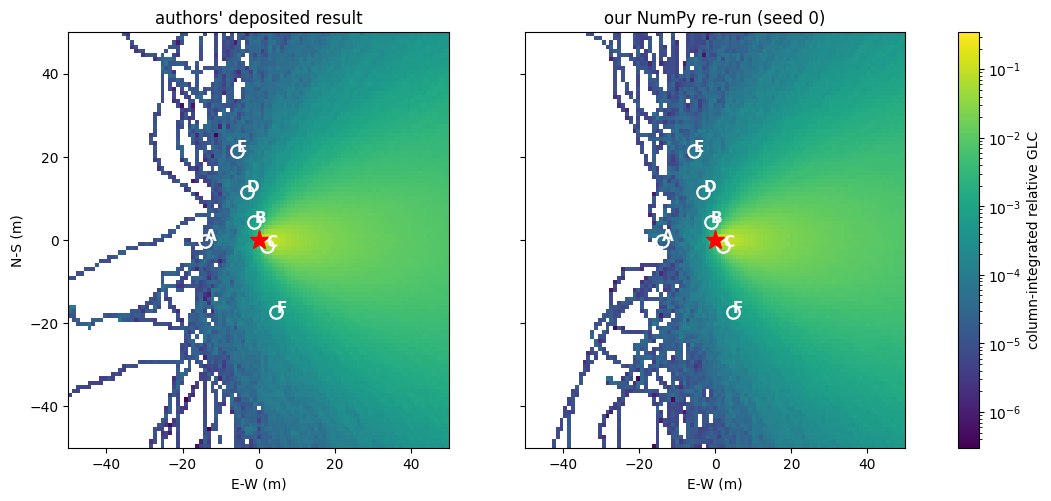

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)
vmax = max(cc[m].max(), cd[m].max()); vmin = min(cc[m].min(), cd[m].min())
for ax, F, lab in [(axes[0], cd, "authors' deposited result"), (axes[1], cc, "our NumPy re-run (seed 0)")]:
    pc = ax.pcolormesh(ec, nc, np.where(F > 0, F, np.nan), shading="auto",
                       norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))
    ax.plot(edLocs[:,0], edLocs[:,1], "o", mfc="none", mec="w", ms=9, mew=1.6)
    for k, lab2 in enumerate("ABCDEF"): ax.annotate(lab2, edLocs[k], color="w", fontsize=11, weight="bold")
    ax.plot(0, 0, "r*", ms=14); ax.set_xlabel("E-W (m)"); ax.set_title(lab)
axes[0].set_ylabel("N-S (m)")
plt.colorbar(pc, ax=axes, label="column-integrated relative GLC")
plt.show()

## Interpretation and limitations

**What was verified in this run**
- The authors' deposited 45-min results reproduce the fusion numbers obtained here. Using the paper's Table 1 measured concentrations, the pooled Pearson R computed **in this run is 0.47** (median-Q variant 0.44; without per-interval Q-scaling 0.14), while the paper reports **R = 0.19** for 45-min windows (Results → Modeling results). The remaining input, the authors' private `measuredConcentrationsAndErrors.mat`, is not in the deposit, so this difference is documented but unresolved; all other inputs and operations follow the authors' code exactly.
- The LS model was re-run from the authors' own equations and parameters for one interval; the resulting field agrees with the deposited result to Monte-Carlo noise (Spearman ≈ 0.99 on jointly covered cells with the correct interval pairing).

**Limitations (EN)**
- Partial demonstration: one averaging window (45 min), one re-simulated interval; paper-wide results (1-min/5-min R values, far-field capability figure, emission diurnal cycle across all intervals) are **not** reproduced here.
- `measuredConcentrationsAndErrors.mat` (author's own file, not in the deposit) was reconstructed; Table 1 rounding limits the agreement.
- Monte-Carlo noise differs from the authors' MATLAB runs (different RNG); the safety step cap never triggered in validation.

**限界（JA）**: 本実行は45分平均窓の部分的再現です。1分・5分窓（R=0.71/0.84）、遠距離能力解析、日変化解析全体は対象外。測定濃度はTable 1（小数2桁）由来のため丸め誤差があります。

**References**: paper DOI 10.1007/s10661-026-15632-3 (PMC13429552); deposit DOI 10.7294/25733604.v1 (files 55052897, 55052885, 55124093; CC0; code MIT © 2025 B. Nimmala); Aylor & Flesch (2001) *J. Appl. Meteor.* 40:966; Flesch et al. (1995) *Bound.-Layer Meteor.* 74:113 as cited by the paper's methods. PhenoPaper investigation `p-31395b78d4983e57d3118f644d1e91b1-20260930T122832Z-3656259` was used as research guidance only.